Data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# We don't use seasonal_decompose yet, but keep the import handy
from statsmodels.tsa.seasonal import seasonal_decompose

# Set display options for better viewing
pd.set_option('display.max_columns', None)

# Define the file path to the Excel file
file_path = '../data/Tourist accomodation From 2007.xlsx'

# Load the data using pd.read_excel()
# We assume the main data is on the first sheet (sheet_name=0)
try:
    df_raw = pd.read_excel(file_path, sheet_name=0)
    print("SUCCESS: Data loaded using pd.read_excel().")
except FileNotFoundError:
    print(f"Error: File not found at path: {file_path}")
    print("Please ensure the file is in the 'data/' folder and the name matches exactly.")
    df_raw = pd.DataFrame() # Create an empty DataFrame to prevent errors

if not df_raw.empty:
    print("Shape of the raw data:", df_raw.shape)
    print("\n--- Raw Data Head (Wide Format) ---")
    print(df_raw.head(2))

SUCCESS: Data loaded using pd.read_excel().
Shape of the raw data: (75, 233)

--- Raw Data Head (Wide Format) ---
     H01                   H02     H03                                    H04  \
0  P6410  Tourism Accomodation  A64100  Stay units available - Total industry   
1  P6410  Tourism Accomodation  A64101          Stay units available - Hotels   

   H15             H16       H17      H25 _LABEL_  MO012007  MO022007  \
0  NaN  Actual figures  Thousand  MONTHLY     NaN     140.9     141.1   
1  NaN  Actual figures  Thousand  MONTHLY     NaN      67.0      67.2   

   MO032007  MO042007  MO052007  MO062007  MO072007  MO082007  MO092007  \
0     141.5     139.9     139.6     139.9     139.7     139.6     139.7   
1      67.5      67.5      67.2      67.2      67.2      67.2      67.2   

   MO102007  MO112007  MO122007  MO012008  MO022008  MO032008  MO042008  \
0     138.7     139.2     139.1     137.0     138.5     137.6     139.0   
1      67.2      67.2      67.2      66.1     

Wide-to-Long Transformation (pd.melt())

In [4]:
# All columns that are NOT the time series data (MO012007, etc.)
# We will inspect H01 through H25 and the _LABEL_ column.

# Identify the columns to keep (all columns up to the 9th index)
id_vars_all = df_raw.columns[:9].tolist()

# The date columns remain the same (from index 9 onwards)
value_vars = df_raw.columns[9:]

# Apply melt function, keeping ALL metadata
df_long_diagnostic = df_raw.melt(
    id_vars=id_vars_all,
    value_vars=value_vars,
    var_name='Date_Code',
    value_name='Value'
)

# --- Filter and Diagnose ---
TARGET_METRIC = 'Occupancy rate - Total industry'
df_target_diagnostic = df_long_diagnostic[
    df_long_diagnostic['H04'] == TARGET_METRIC
].copy()

# List the columns that still vary for the filtered metric
print("--- Unique values for key metadata columns (Occupancy Rate) ---")

# Let's check H01, H02, H03, H15, H16, H25
for col in ['H01', 'H02', 'H03', 'H15', 'H16', 'H25']:
    unique_values = df_target_diagnostic[col].unique()
    # Only print columns with more than one unique value (i.e., the columns that vary)
    if len(unique_values) > 1:
        print(f"\nColumn {col} (Varies):")
        print(unique_values)

--- Unique values for key metadata columns (Occupancy Rate) ---

Column H03 (Varies):
['C64100' 'TOT_OCC_D11']

Column H16 (Varies):
['Actual figures' 'Seasonally adjusted']


Date Conversion and Metric Filtering

In [7]:
# The df_long_diagnostic DataFrame, which contains all metadata, is used here

# Define the three criteria based on the most likely correct codes:
TARGET_METRIC = 'Occupancy rate - Total industry'
TOTAL_CODE = 'C64100'        # Assuming C64100 is the code for the Total Industry (Unadjusted)
STATUS_TYPE = 'Actual figures' # We choose the unadjusted data to model seasonality

df_final_series = df_long_diagnostic[
    (df_long_diagnostic['H04'] == TARGET_METRIC) &
    (df_long_diagnostic['H03'] == TOTAL_CODE) &
    (df_long_diagnostic['H16'] == STATUS_TYPE)
].copy()

# --- Date Cleaning (Must be repeated here as the DataFrame is new) ---
# Convert Date_Code to Datetime
df_final_series['Year'] = df_final_series['Date_Code'].str[4:8]
df_final_series['Month'] = df_final_series['Date_Code'].str[2:4]
df_final_series['Date'] = pd.to_datetime(
    df_final_series['Year'] + '-' + df_final_series['Month'] + '-01'
)

# Set the Date as index and drop unnecessary columns
df_final_series.set_index('Date', inplace=True)
df_final_series = df_final_series[['Value']] # Keep only the 'Value' column

# Drop any remaining NaN values
df_final_series.dropna(subset=['Value'], inplace=True)

# The time series we want is the 'Value' column
occupancy_series = df_final_series['Value']


print("--- Final Filtered Series Head ---")
print(df_final_series.head())
print(f"\nFinal series length: {len(occupancy_series)} monthly observations.")

# CORRECTED LINE: Use df_final_series to check the index for duplicates
duplicates_check = df_final_series.index.duplicated().sum() 
print(f"Number of duplicate dates: {duplicates_check}")

--- Final Filtered Series Head ---
            Value
Date             
2007-01-01   45.9
2007-02-01   53.4
2007-03-01   51.6
2007-04-01   51.4
2007-05-01   46.5

Final series length: 224 monthly observations.
Number of duplicate dates: 0


In [3]:
# Extract Month and Year from 'Date_Code' (e.g., MO012007 -> 01, 2007)
df_long['Year'] = df_long['Date_Code'].str[4:8]
df_long['Month'] = df_long['Date_Code'].str[2:4]

# Create the Datetime Index (always set to the 1st of the month)
df_long['Date'] = pd.to_datetime(df_long['Year'] + '-' + df_long['Month'] + '-01')

# Drop intermediate and unnecessary columns
df_long.drop(columns=['Date_Code', 'Year', 'Month'], inplace=True)

# Define the target metric
TARGET_METRIC = 'Occupancy rate - Total industry'

# Filter for the target series and create a new DataFrame
df_target = df_long[df_long['Metric_Description'] == TARGET_METRIC].copy()

# Set the 'Date' column as the index (required for time series models)
df_target.set_index('Date', inplace=True)

# Handle potential missing values (drop rows where the 'Value' is missing)
df_target.dropna(subset=['Value'], inplace=True)

# We only need the 'Value' column going forward
income_series = df_target['Value'] 

print("\n--- Final Target Series Head ---")
print(df_target.head())
print(f"\nFinal series length: {len(income_series)} monthly observations.")


--- Final Target Series Head ---
                         Metric_Description        Unit  Value
Date                                                          
2007-01-01  Occupancy rate - Total industry  Percentage   45.9
2007-01-01  Occupancy rate - Total industry  Percentage   49.3
2007-02-01  Occupancy rate - Total industry  Percentage   53.4
2007-02-01  Occupancy rate - Total industry  Percentage   49.6
2007-03-01  Occupancy rate - Total industry  Percentage   51.6

Final series length: 448 monthly observations.


Exploratory Data Analysis (EDA) and Decomposition

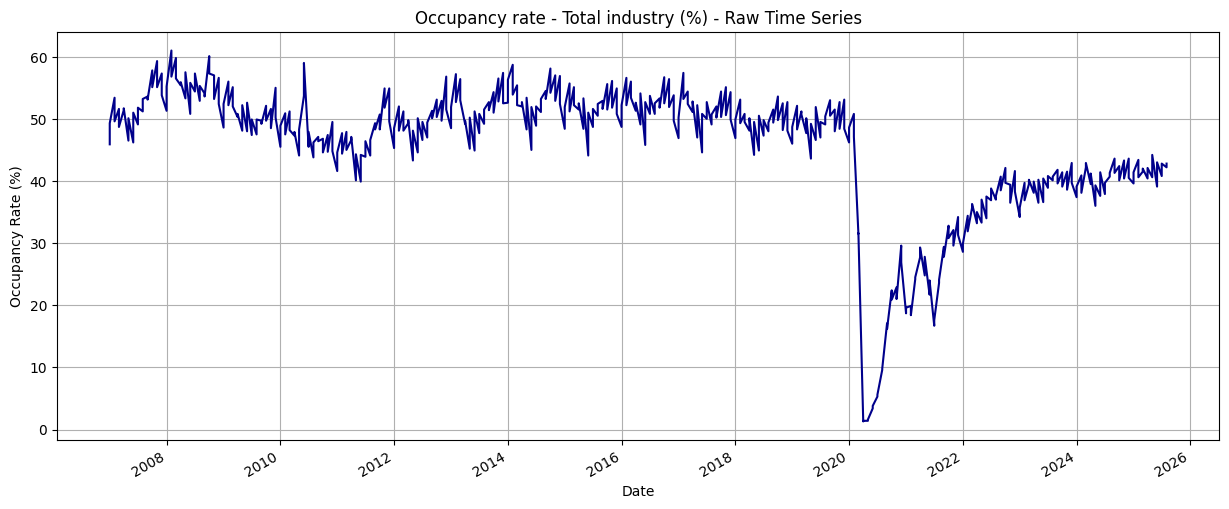

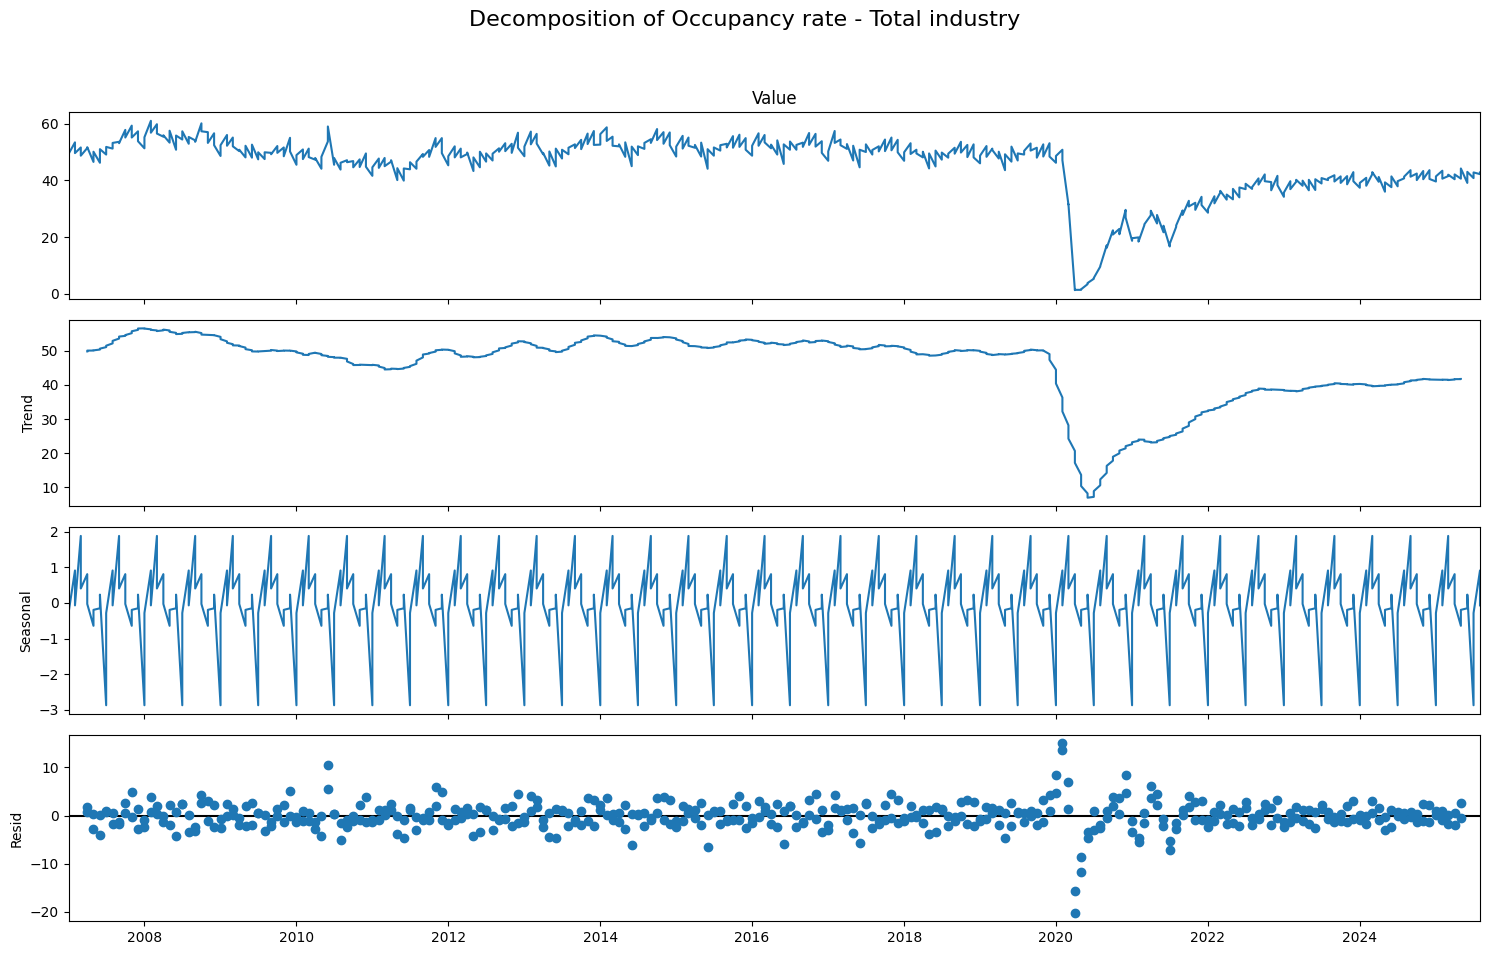

In [8]:
# 1. Plot the raw time series
plt.figure(figsize=(15, 6))
income_series.plot(title=f'{TARGET_METRIC} (%) - Raw Time Series', color='darkblue')
plt.ylabel('Occupancy Rate (%)')
plt.grid(True)
plt.savefig('occupancy_rate_raw_series.png') # Save for the portfolio report
plt.show()

# 2. Decompose the series (Additive model, period=12 for monthly data)
decomposition = seasonal_decompose(income_series, model='additive', period=12)

fig = decomposition.plot()
fig.set_size_inches(15, 10)
fig.suptitle(f'Decomposition of {TARGET_METRIC}', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('occupancy_rate_decomposition.png') # Save for the portfolio report
plt.show()

Seasonal AutoRegressive Integrated Moving Average (SARIMA) parameters. Classic Modelling

--- ADF Test on Original Series (Check for Non-Stationarity) ---
ADF Statistic: -2.0643
P-value: 0.2591

--- ADF Test on 1st Difference (Confirming d=1) ---
ADF Statistic: -4.5520
P-value: 0.0002


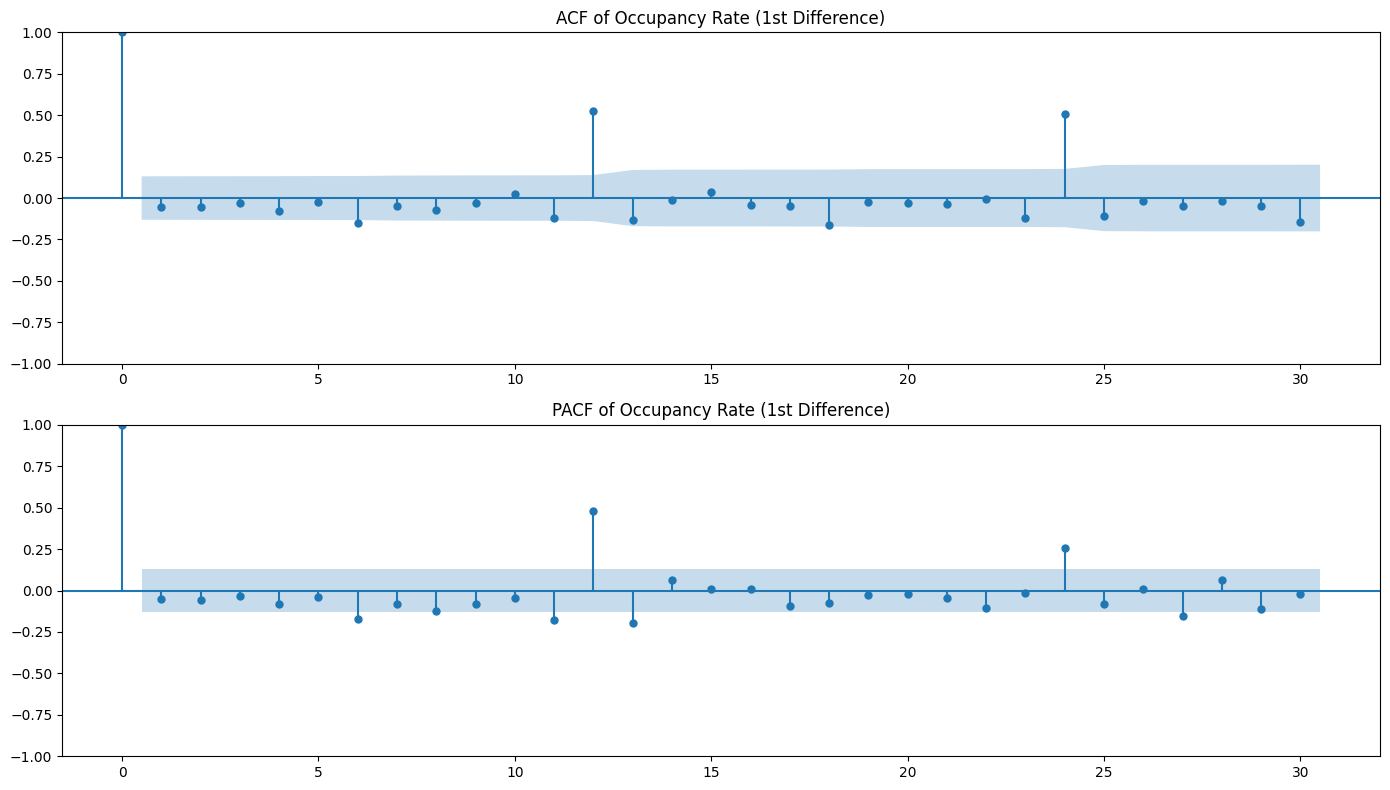

In [9]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


# Use the 'occupancy_series' created in the final cleaning step
occupancy_series = df_final_series['Value'] 

# --- 1. ADF Test on Original Series (Should fail, P-value > 0.05) ---
result_original = adfuller(occupancy_series.dropna())
print("--- ADF Test on Original Series (Check for Non-Stationarity) ---")
print(f"ADF Statistic: {result_original[0]:.4f}")
print(f"P-value: {result_original[1]:.4f}")
# Expected result: P-value is high, confirming d >= 1 is needed.

# --- 2. ADF Test on the First Difference (d=1) ---
occupancy_diff1 = occupancy_series.diff().dropna()
result_diff1 = adfuller(occupancy_diff1)
print("\n--- ADF Test on 1st Difference (Confirming d=1) ---")
print(f"ADF Statistic: {result_diff1[0]:.4f}")
print(f"P-value: {result_diff1[1]:.4f}")
# Expected result: P-value is low (e.g., < 0.05), confirming d=1 is sufficient.

# --- 3. Plot ACF and PACF for Parameter Selection ---
# We use the differenced series to guide the remaining parameter selection.
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# ACF Plot: Look for spikes at lag 12, 24, etc. (for Q) and lag 1 (for q)
plot_acf(occupancy_diff1, lags=30, ax=axes[0], title='ACF of Occupancy Rate (1st Difference)')

# PACF Plot: Look for spikes at lag 12, 24, etc. (for P) and lag 1 (for p)
plot_pacf(occupancy_diff1, lags=30, ax=axes[1], title='PACF of Occupancy Rate (1st Difference)')

plt.tight_layout()
plt.show()

Fit the SARIMAX Model

e:\ML Project\SA Tourist Accomodation Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
e:\ML Project\SA Tourist Accomodation Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Fitting SARIMAX model...
SARIMAX Model Summary:
                                     SARIMAX Results                                      
Dep. Variable:                              Value   No. Observations:                  224
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 12)   Log Likelihood                -546.250
Date:                            Fri, 21 Nov 2025   AIC                           1102.500
Time:                                    00:03:37   BIC                           1119.211
Sample:                                01-01-2007   HQIC                          1109.256
                                     - 08-01-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5750      0.181     -3.172      0.002      -0.930

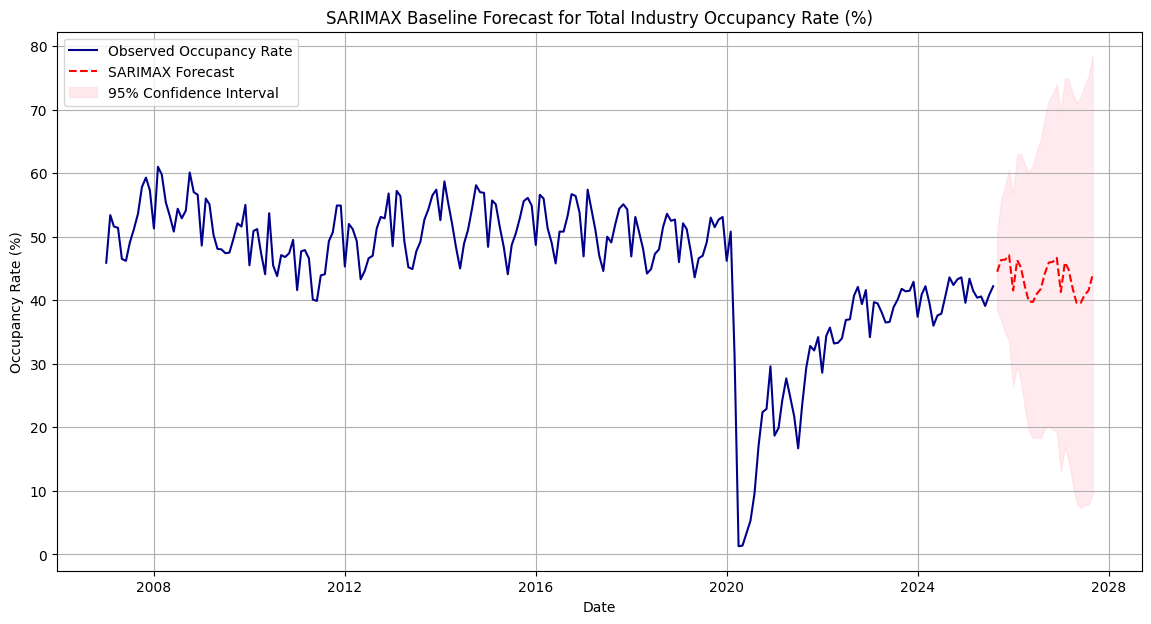

In [10]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# --- Model Parameters (SARIMA(1, 1, 1)(1, 0, 1)12) ---
# d=1 confirmed by ADF test
order = (1, 1, 1)        
seasonal_order = (1, 0, 1, 12) # P=1, Q=1 confirmed by spikes at Lag 12

# Instantiate and fit the SARIMAX model
sarimax_model = SARIMAX(
    occupancy_series,
    order=order,
    seasonal_order=seasonal_order,
    # These settings help the model converge when there are massive outliers (like 2020)
    enforce_stationarity=False,
    enforce_invertibility=False
)

print("Fitting SARIMAX model...")
sarimax_results = sarimax_model.fit(disp=False)
print("SARIMAX Model Summary:")
print(sarimax_results.summary())

# --- Generate Forecast and Plot ---
n_forecast = 24 # Forecast for the next 2 years
forecast_steps = len(occupancy_series) + n_forecast

forecast = sarimax_results.get_prediction(start=len(occupancy_series), end=forecast_steps)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

plt.figure(figsize=(14, 7))
plt.plot(occupancy_series, label='Observed Occupancy Rate', color='darkblue')

plt.plot(forecast_mean, label='SARIMAX Forecast', color='red', linestyle='--')

# Plot the 95% confidence interval
plt.fill_between(
    conf_int.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color='pink',
    alpha=0.3,
    label='95% Confidence Interval'
)

plt.title('SARIMAX Baseline Forecast for Total Industry Occupancy Rate (%)')
plt.xlabel('Date')
plt.ylabel('Occupancy Rate (%)')
plt.legend()
plt.grid(True)
plt.show()

Feature Engineering for XGBoost

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# --- 1. Prepare the Data Frame for ML ---
df_ml = df_final_series.copy()
df_ml.reset_index(inplace=True) # Move 'Date' from index to a column

# --- 2. Create Time-Based Features (Capture Seasonality and Trend) ---
df_ml['month'] = df_ml['Date'].dt.month
df_ml['year'] = df_ml['Date'].dt.year
df_ml['quarter'] = df_ml['Date'].dt.quarter
# We can use Sine/Cosine transformation for month to help ML models perceive circular time:
df_ml['month_sin'] = np.sin(2 * np.pi * df_ml['month'] / 12)
df_ml['month_cos'] = np.cos(2 * np.pi * df_ml['month'] / 12)

# --- 3. Create Lag Features (Captures Autocorrelation, p and P components) ---
# Lag 1: Value from the previous month
df_ml['lag_1'] = df_ml['Value'].shift(1)
# Lag 12: Value from the same month last year (The most powerful seasonal feature)
df_ml['lag_12'] = df_ml['Value'].shift(12)

# --- 4. Create Rolling Window Features (Captures Local Trend and Volatility) ---
# 3-month rolling mean (short-term trend)
df_ml['rolling_mean_3'] = df_ml['Value'].rolling(window=3).mean().shift(1)
# 12-month rolling standard deviation (volatility)
df_ml['rolling_std_12'] = df_ml['Value'].rolling(window=12).std().shift(1)

# --- 5. Create Anomaly Flag (COVID-19 Structural Break) ---
# This explicitly tells the XGBoost model to treat this period differently.
df_ml['covid_flag'] = 0
df_ml.loc[(df_ml['Date'] >= '2020-03-01') & (df_ml['Date'] <= '2021-12-01'), 'covid_flag'] = 1

# Drop rows with NaN values created by lags/rolling features (first 12 rows are dropped)
df_ml.dropna(inplace=True)

print("--- ML Feature Data Head ---")
print(df_ml.head())
print(f"\nFinal ML feature set size: {len(df_ml)}")

--- ML Feature Data Head ---
         Date  Value  month  year  quarter  month_sin     month_cos  lag_1  \
12 2008-01-01   51.3      1  2008        1   0.500000  8.660254e-01   57.3   
13 2008-02-01   61.0      2  2008        1   0.866025  5.000000e-01   51.3   
14 2008-03-01   59.8      3  2008        1   1.000000  6.123234e-17   61.0   
15 2008-04-01   55.4      4  2008        2   0.866025 -5.000000e-01   59.8   
16 2008-05-01   53.3      5  2008        2   0.500000 -8.660254e-01   55.4   

    lag_12  rolling_mean_3  rolling_std_12  covid_flag  
12    45.9       58.133333        4.574327           0  
13    53.4       55.966667        4.174045           0  
14    51.6       56.533333        4.861000           0  
15    51.4       57.366667        5.206545           0  
16    46.5       58.733333        5.173263           0  

Final ML feature set size: 212


Train and Evaluate XGBoost


--- Model Evaluation (XGBoost) ---
Root Mean Squared Error (RMSE): 2.7077
Mean Absolute Percentage Error (MAPE): 5.36%


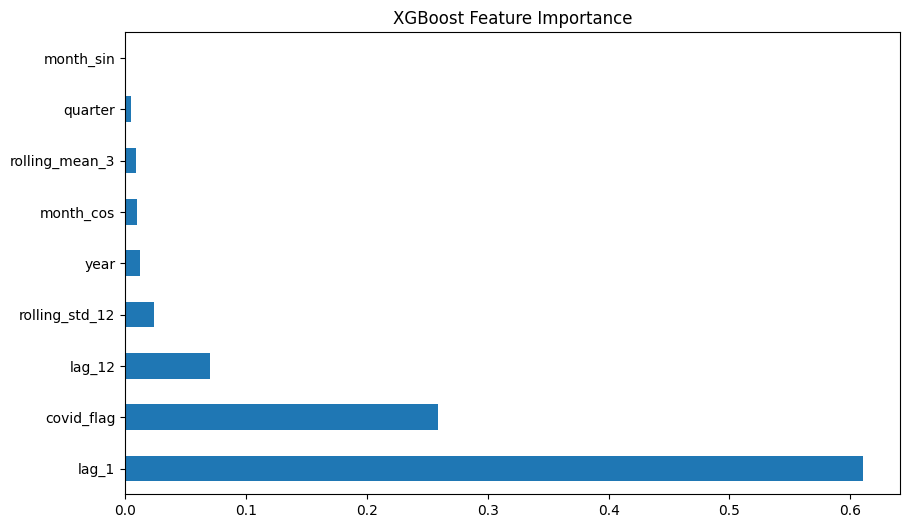

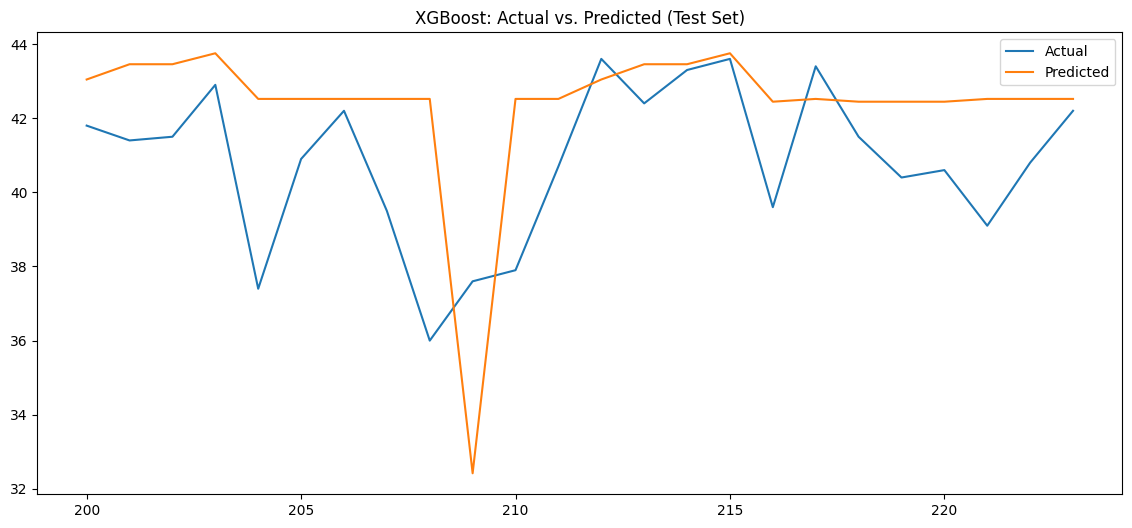

In [13]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np # Ensure NumPy is imported

# --- 1. Prepare Data for XGBoost (Same as before) ---
TARGET = 'Value'
FEATURES = [col for col in df_ml.columns if col not in ['Date', TARGET, 'month']]

X = df_ml[FEATURES]
y = df_ml[TARGET]

# --- 2. Time-Aware Split (Same as before) ---
TEST_SIZE = 24 
X_train = X.iloc[:-TEST_SIZE]
X_test = X.iloc[-TEST_SIZE:]
y_train = y.iloc[:-TEST_SIZE]
y_test = y.iloc[-TEST_SIZE:]

# --- 3. Train XGBoost Model (Same as before) ---
xgb_model = XGBRegressor(
    n_estimators=1000, 
    learning_rate=0.03, 
    early_stopping_rounds=50, 
    random_state=42
)

xgb_model.fit(
    X_train, 
    y_train, 
    eval_set=[(X_test, y_test)], 
    verbose=False
)

# --- 4. Evaluate Model ---
y_pred = xgb_model.predict(X_test)

# Calculate MSE first
mse = mean_squared_error(y_test, y_pred) 

# CORRECTED: Calculate RMSE using NumPy's sqrt function
rmse = np.sqrt(mse) 

# Calculate MAPE (Business Metric)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100 

print("\n--- Model Evaluation (XGBoost) ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

# --- 5. Feature Importance and Plot (Same as before) ---
importance = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importance.plot(kind='barh', title='XGBoost Feature Importance')
plt.show()

# --- 6. Plot Test vs. Prediction ---
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
comparison_df.plot(figsize=(14, 6), title='XGBoost: Actual vs. Predicted (Test Set)')
plt.show()

In [ ]:
Model Persistance with joblib

In [14]:
import joblib
import os

# Ensure the models folder exists
if not os.path.exists('../models'):
    os.makedirs('../models')

# Save the trained XGBoost model
model_path = '../models/xgboost_occupancy_model.joblib'
joblib.dump(xgb_model, model_path)

print(f"\nModel saved successfully to: {model_path}")


Model saved successfully to: ../models/xgboost_occupancy_model.joblib
